In [26]:
import sys
from pathlib import Path

# go from notebooks/ → project root
ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT))

print("ROOT added to path:", ROOT)

ROOT added to path: /workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization


📥 Loading: /workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization/data/processed/clean.parquet
Shape: (50000, 55)
  channelGrouping      date        fullVisitorId  \
0  Organic Search  20160902  1131660440785968503   
1  Organic Search  20160902   377306020877927890   
2  Organic Search  20160902  3895546263509774583   
3  Organic Search  20160902  4763447161404445595   
4  Organic Search  20160902    27294437909732085   

                        sessionId  socialEngagementType     visitId  \
0  1131660440785968503_1472830385  Not Socially Engaged  1472830385   
1   377306020877927890_1472880147  Not Socially Engaged  1472880147   
2  3895546263509774583_1472865386  Not Socially Engaged  1472865386   
3  4763447161404445595_1472881213  Not Socially Engaged  1472881213   
4    27294437909732085_1472822600  Not Socially Engaged  1472822600   

   visitNumber      visitStartTime device_browser  \
0            1 2016-09-02 15:33:05         Chrome   
1            1 201

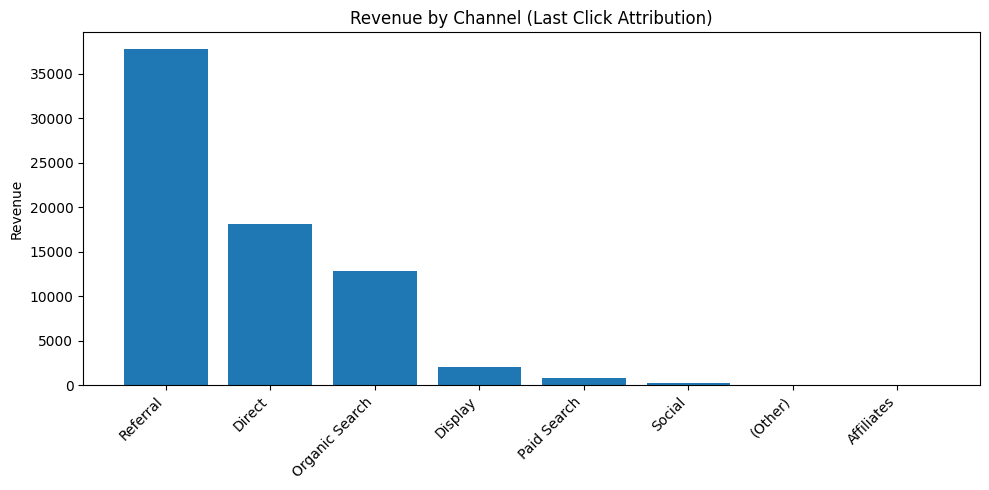

In [27]:
from src.data_loader import load_data
from src.attribution import last_click_attribution
import matplotlib.pyplot as plt


# ----------------------------
# 1. LOAD PREPROCESSED DATA
# ----------------------------
df = load_data("data/processed/clean.parquet")

print("Shape:", df.shape)
print(df.head())

# ----------------------------
# 2. BASIC EDA
# ----------------------------
print("\nData Summary:")
print(df.describe(include="all"))

print("\nMissing Values:")
print(df.isnull().sum())

# ----------------------------
# 3. ATTRIBUTION MODEL
# ----------------------------
attribution = last_click_attribution(df)

print("\nAttribution sample:")
print(attribution.head())

# ----------------------------
# 4. PLOT ATTRIBUTION
# ----------------------------
def plot_attribution(attribution):

    # Ensure aggregation (safe even if already aggregated)
    df_plot = attribution.copy()

    if 'channelGrouping' in df_plot.columns and 'revenue' in df_plot.columns:
        df_plot = df_plot.groupby('channelGrouping', as_index=False)['revenue'].sum()

    # Sort for clarity
    df_plot = df_plot.sort_values('revenue', ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(df_plot['channelGrouping'], df_plot['revenue'])

    plt.xticks(rotation=45, ha='right')
    plt.title("Revenue by Channel (Last Click Attribution)")
    plt.ylabel("Revenue")

    plt.tight_layout()
    plt.show()

# Call plot
plot_attribution(attribution)

In [ ]:
from src.preprocessing import save_to_excel
# Step 2: save cleaned data
save_to_excel(cleaned_data, path)

💾 Saved cleaned data to outputs/cleaned_non_missing.xlsx


Data Sanity Checks

1.how much "not available in demo dataset" existed

2.duplicate sessions (visitId)

3.duplicate users (fullVisitorId)

In [14]:
(df == "not available in demo dataset").sum().sum()

np.int64(933148)

In [15]:
na_counts = (df == "not available in demo dataset").sum().sort_values(ascending=False)
na_counts

device_mobileInputSelector                           50000
device_mobileDeviceInfo                              50000
device_mobileDeviceMarketingName                     50000
device_operatingSystemVersion                        50000
device_mobileDeviceBranding                          50000
device_browserVersion                                50000
device_browserSize                                   50000
device_flashVersion                                  50000
device_language                                      50000
device_screenColors                                  50000
device_screenResolution                              50000
device_mobileDeviceModel                             50000
geoNetwork_longitude                                 50000
geoNetwork_networkLocation                           50000
geoNetwork_cityId                                    50000
geoNetwork_latitude                                  50000
trafficSource_adwordsClickInfo.criteriaParameters    500

In [17]:
na_percent = (df == "not available in demo dataset").mean().sort_values(ascending=False) * 100
na_percent

device_mobileInputSelector                           100.000
device_mobileDeviceInfo                              100.000
device_mobileDeviceMarketingName                     100.000
device_operatingSystemVersion                        100.000
device_mobileDeviceBranding                          100.000
device_browserVersion                                100.000
device_browserSize                                   100.000
device_flashVersion                                  100.000
device_language                                      100.000
device_screenColors                                  100.000
device_screenResolution                              100.000
device_mobileDeviceModel                             100.000
geoNetwork_longitude                                 100.000
geoNetwork_networkLocation                           100.000
geoNetwork_cityId                                    100.000
geoNetwork_latitude                                  100.000
trafficSource_adwordsCli

In [30]:
import importlib
import src.preprocessing as p
importlib.reload(p)

<module 'src.preprocessing' from '/workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization/src/preprocessing.py'>

In [31]:
from src.preprocessing import clean_placeholders, save_to_excel

path = input("Enter output file path (e.g. outputs/data.xlsx): ")

df_cleaned, dropped_cols = clean_placeholders(df)

save_to_excel(df_cleaned, path)

🧹 Dropped 17 fully-placeholder columns
🧹 Replaced placeholder values with NaN
💾 Saved cleaned data to outputs/cleaned_non_missing.xlsx


Revenue distribution

How skewed is revenue?

Are most users non-buyers?

Conversion rate analysis


Traffic source performance

Device behavior analysis

Mobile vs desktop conversion?

OS differences?

Geography insights

country-level revenue

city-level conversion rate

Time-based patterns

Do weekends convert more?

Time-of-day effects?

Funnel behavior

Revenue per channel

High-value user analysis (VIP customers)

repeat buyers?

single high-ticket buyers?

Correlation insights

Business questions:

Which channels bring real revenue vs vanity traffic?

Which countries are overfunded / underperforming?

What is the conversion funnel drop-off point?

Which device segment is underperforming?

What is the true ROI proxy per channel?